# Exploratory Data Analysis: Impact of the Belt and Road Initiative (BRI)
This notebook performs an EDA on macroeconomic, infrastructure, and governance indicators for selected countries to evaluate the quasi-experimental impact of the BRI announced in 2013.

**Methodology & Grouping:**
* **Treatment Group (BRI):** Myanmar, Lao PDR, Cambodia, Pakistan, Sri Lanka Kazakhstan, Kyrgyz Republic, Uzbekistan, Kenya, Ethiopia, Serbia, Greece.
* **Control Group (Non-BRI):** India, Viet Nam, Tanzania.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import matplotlib.colors as mcolors

sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams['figure.dpi'] = 120

INTERVENTION_YEAR = 2013
BASELINE_YEAR = 2019
FILE_NAME = 'Data.csv'

print("Setup complete. Ready for data processing.")

Setup complete. Ready for data processing.


In [12]:
df_raw = pd.read_csv(FILE_NAME)

valid_countries = df_raw['Country Name'].dropna().unique()
metadata_flags = ['Data from database: World Development Indicators', 'Last Updated: 02/24/2026']
df = df_raw[~df_raw['Country Name'].isin(metadata_flags)].copy()

id_vars = ['Country Name', 'Country Code', 'Series Name', 'Series Code']
year_cols = [col for col in df.columns if 'YR' in col]

df_long = pd.melt(df, id_vars=id_vars, value_vars=year_cols, var_name='Year_Str', value_name='Value')

df_long['Year'] = df_long['Year_Str'].str.extract(r'(\d{4})').astype(int)
df_long.drop(columns=['Year_Str'], inplace=True)
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

df_panel = df_long.pivot_table(index=['Country Name', 'Country Code', 'Year'], 
                               columns='Series Name', 
                               values='Value').reset_index()

print(f"Panel data shape: {df_panel.shape}")
df_panel.head()

Panel data shape: (400, 36)


Series Name,Country Name,Country Code,Year,Access to electricity (% of population),"Air transport, freight (million ton-km)","Air transport, passengers carried","Central government debt, total (% of GDP)",Container port traffic (TEU: 20 foot equivalent units),Control of Corruption: Estimate,Control of Corruption: Number of Sources,...,Individuals using the Internet (% of population),Multidimensional poverty headcount ratio (UNDP) (% of population),Political Stability and Absence of Violence/Terrorism: Estimate,Political Stability and Absence of Violence/Terrorism: Number of Sources,"Railways, goods transported (million ton-km)","Railways, passengers carried (million passenger-km)","Tariff rate, applied, simple mean, all products (%)","Tariff rate, most favored nation, weighted mean, all products (%)","Unemployment, total (% of total labor force) (modeled ILO estimate)","Unemployment, total (% of total labor force) (national estimate)"
0,Cambodia,KHM,2001,9.5,NaN,NaN,NaN,NaN,NaN,NaN,...,0.076956,NaN,NaN,NaN,NaN,33.0,16.74,16.49,0.778,2.055
1,Cambodia,KHM,2002,13.1,4.087,124847.0,NaN,NaN,-0.990784,3.0,...,0.226983,NaN,-0.722165,3.0,NaN,NaN,16.28,16.28,0.862,NaN
2,Cambodia,KHM,2003,19.3,3.265,164515.0,NaN,NaN,-0.989836,5.0,...,0.260570,NaN,-0.652009,3.0,92.0,45.0,16.26,16.47,0.909,0.909
3,Cambodia,KHM,2004,14.2,3.143,162132.0,NaN,NaN,-1.058346,6.0,...,0.300437,NaN,-0.407748,4.0,NaN,45.0,NaN,NaN,1.004,7.530
4,Cambodia,KHM,2005,20.5,1.202,168810.0,NaN,NaN,-1.223740,10.0,...,0.317322,NaN,-0.393915,5.0,NaN,45.0,14.09,11.08,1.061,NaN


In [13]:
regions = {
    'BRI - Southeast Asia': ['Myanmar', 'Lao PDR', 'Cambodia'],
    'BRI - South Asia': ['Pakistan', 'Sri Lanka'],
    'BRI - Central Asia': ['Kazakhstan', 'Kyrgyz Republic', 'Uzbekistan'],
    'BRI - Africa': ['Kenya', 'Ethiopia'],
    'BRI - Europe': ['Serbia', 'Greece'],
    'Non-BRI (Control)': ['India', 'Viet Nam', 'Tanzania'],
    'China (Source Country)': ['China']
}

def get_region(country):
    for region, countries in regions.items():
        if country in countries:
            return region
    return 'Other'

df_panel['Region'] = df_panel['Country Name'].apply(get_region)

# Define Difference-in-Differences (DID) groups
control_countries = ['India', 'Viet Nam', 'Tanzania']

def get_did_group(country):
    if country in control_countries:
        return 'Control Group (Non-BRI)'
    elif country == 'China':
        return 'China'
    else:
        return 'BRI Treatment Group'

df_panel['DID_Group'] = df_panel['Country Name'].apply(get_did_group)

# Verification
print("Group Mapping Summary:")
print(df_panel[['Country Name', 'Region', 'DID_Group']].drop_duplicates().value_counts('DID_Group'))
df_panel[['Country Name', 'Region', 'DID_Group']].drop_duplicates().sort_values(by=['DID_Group', 'Region'])

Group Mapping Summary:
DID_Group
BRI Treatment Group        12
Control Group (Non-BRI)     3
China                       1
dtype: int64


Series Name,Country Name,Region,DID_Group
50,Ethiopia,BRI - Africa,BRI Treatment Group
150,Kenya,BRI - Africa,BRI Treatment Group
125,Kazakhstan,BRI - Central Asia,BRI Treatment Group
175,Kyrgyz Republic,BRI - Central Asia,BRI Treatment Group
350,Uzbekistan,BRI - Central Asia,BRI Treatment Group
75,Greece,BRI - Europe,BRI Treatment Group
275,Serbia,BRI - Europe,BRI Treatment Group
250,Pakistan,BRI - South Asia,BRI Treatment Group
300,Sri Lanka,BRI - South Asia,BRI Treatment Group
0,Cambodia,BRI - Southeast Asia,BRI Treatment Group


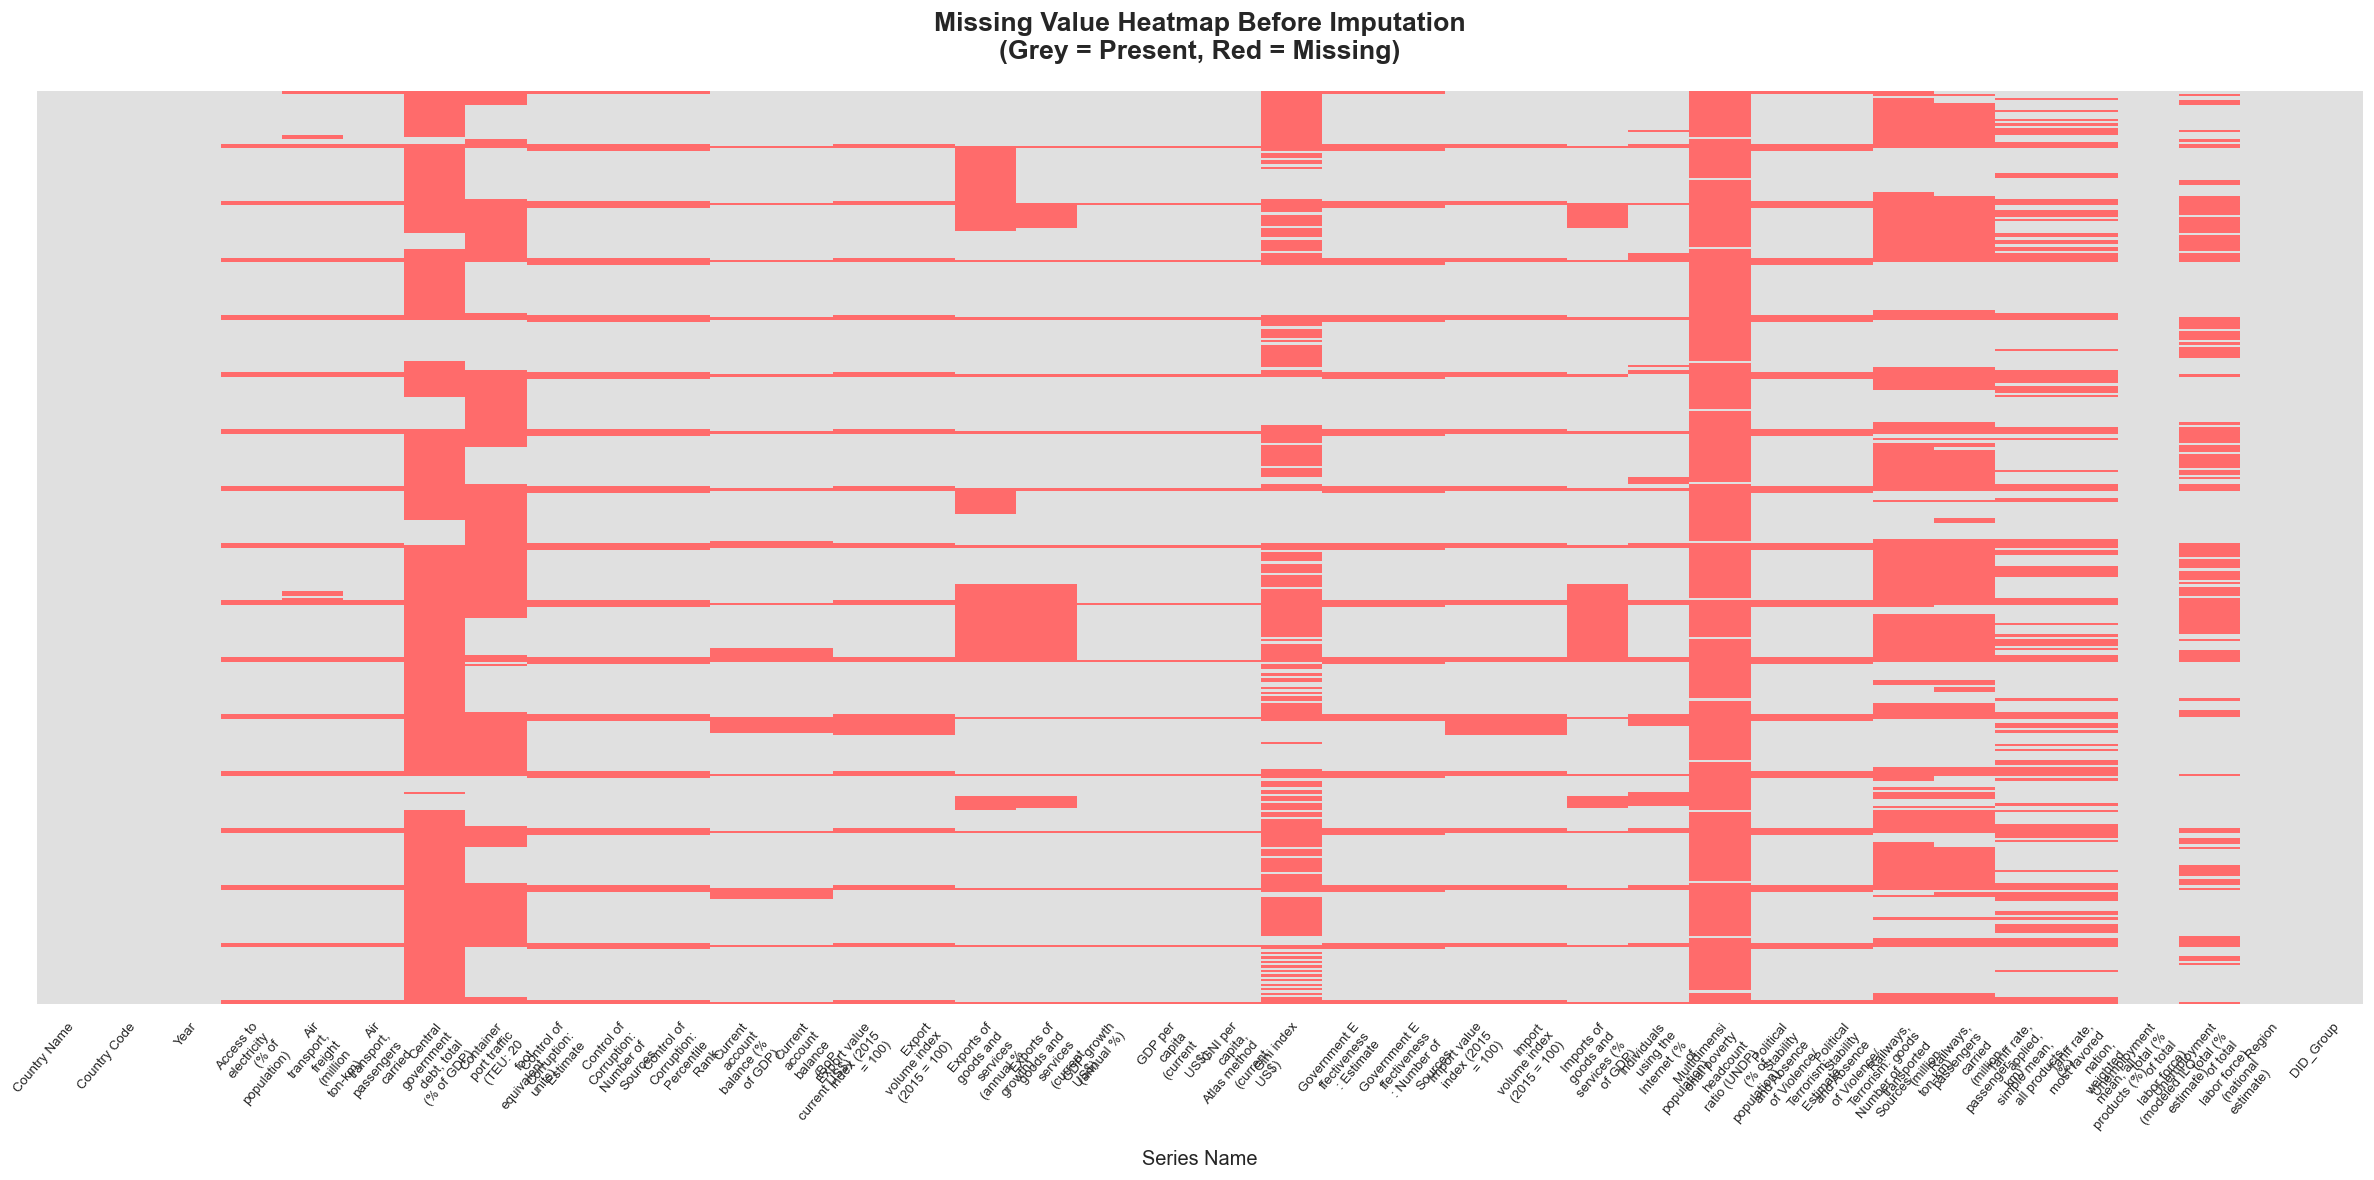

Top 5 indicators with the highest missing rates (%):
Series Name
Multidimensional poverty headcount ratio (UNDP) (% of population)    96.25
Central government debt, total (% of GDP)                            83.25
Gini index                                                           61.00
Railways, goods transported (million ton-km)                         52.50
Container port traffic (TEU: 20 foot equivalent units)               51.50
dtype: float64
Dropping indicators with >80% missing data: ['Central government debt, total (% of GDP)', 'Multidimensional poverty headcount ratio (UNDP) (% of population)']

Final imputed dataset shape: (400, 36)



In [14]:
missing_pct = df_panel.isnull().mean() * 100

wrapped_cols = [textwrap.fill(str(col), width=12) for col in df_panel.columns]

plt.figure(figsize=(20, 10))

cmap_missing = mcolors.ListedColormap(['#E0E0E0', '#FF6B6B'])

ax = sns.heatmap(df_panel.isnull(), 
                 cbar=False, 
                 cmap=cmap_missing, 
                 yticklabels=False)

ax.set_xticklabels(wrapped_cols)

plt.setp(ax.get_xticklabels(), rotation=50, ha="right", rotation_mode="anchor", fontsize=8)
plt.title('Missing Value Heatmap Before Imputation\n(Grey = Present, Red = Missing)', 
          fontsize=16, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5 indicators with the highest missing rates (%):")
print(missing_pct.sort_values(ascending=False).head(5))

# Drop indicators with >80% missing data
threshold = 80.0
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
print(f"Dropping indicators with >80% missing data: {cols_to_drop}\n")

df_cleaned = df_panel.drop(columns=cols_to_drop)

def interpolate_by_group(df_group):
    return df_group.interpolate(method='linear', limit=2, limit_direction='both')

df_imputed = df_cleaned.groupby('Country Name', group_keys=False).apply(interpolate_by_group)

print(f"Final imputed dataset shape: {df_imputed.shape}\n")

C:\Users\60310\AppData\Local\Temp\ipykernel_39624\2715155938.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_baseline[df_baseline['Region'] != 'China (Initiator)'],


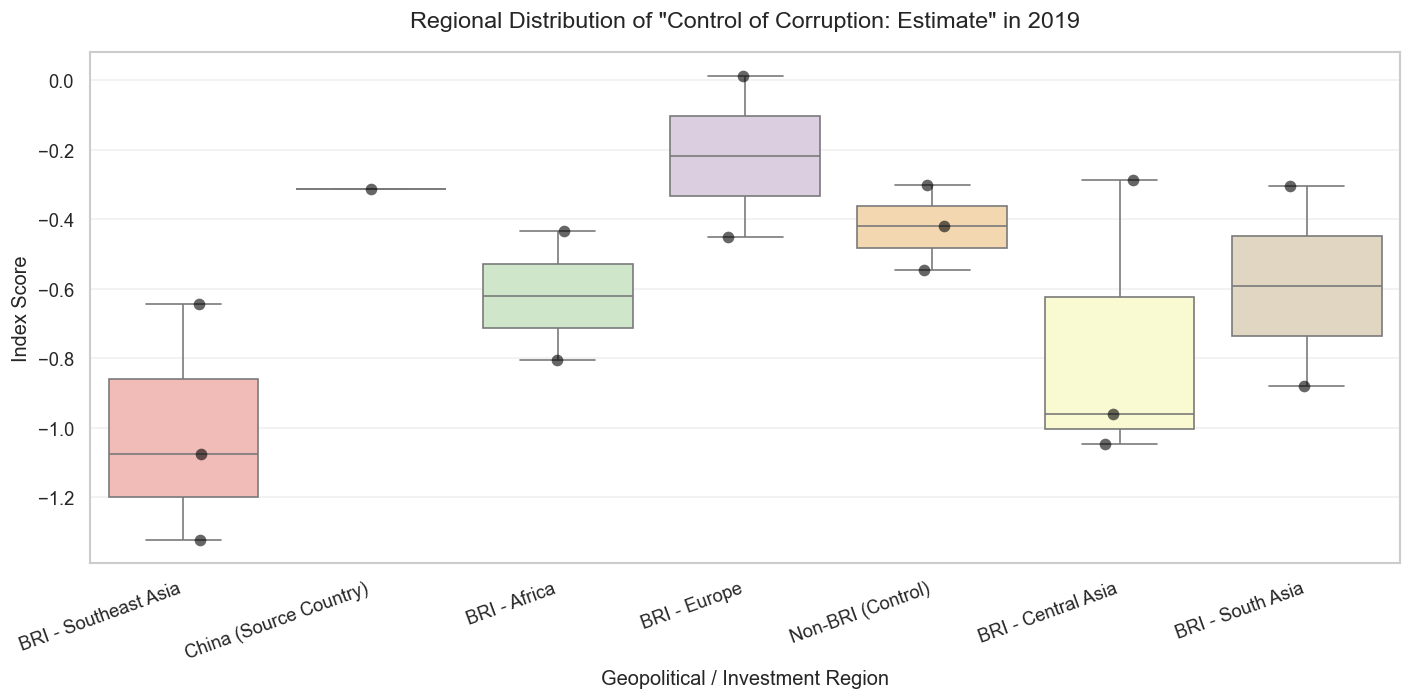

In [15]:
df_baseline = df_imputed[df_imputed['Year'] == BASELINE_YEAR]

indicator_boxplot = 'Control of Corruption: Estimate'

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_baseline[df_baseline['Region'] != 'China (Initiator)'], 
            x='Region', y=indicator_boxplot, palette='Pastel1')
sns.stripplot(data=df_baseline[df_baseline['Region'] != 'China (Initiator)'], 
              x='Region', y=indicator_boxplot, color='black', alpha=0.6, size=7)

plt.title(f'Regional Distribution of "{indicator_boxplot}" in {BASELINE_YEAR}', fontsize=14, pad=15)
plt.xticks(rotation=20, ha='right', fontsize=11)
plt.ylabel('Index Score', fontsize=12)
plt.xlabel('Geopolitical / Investment Region', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

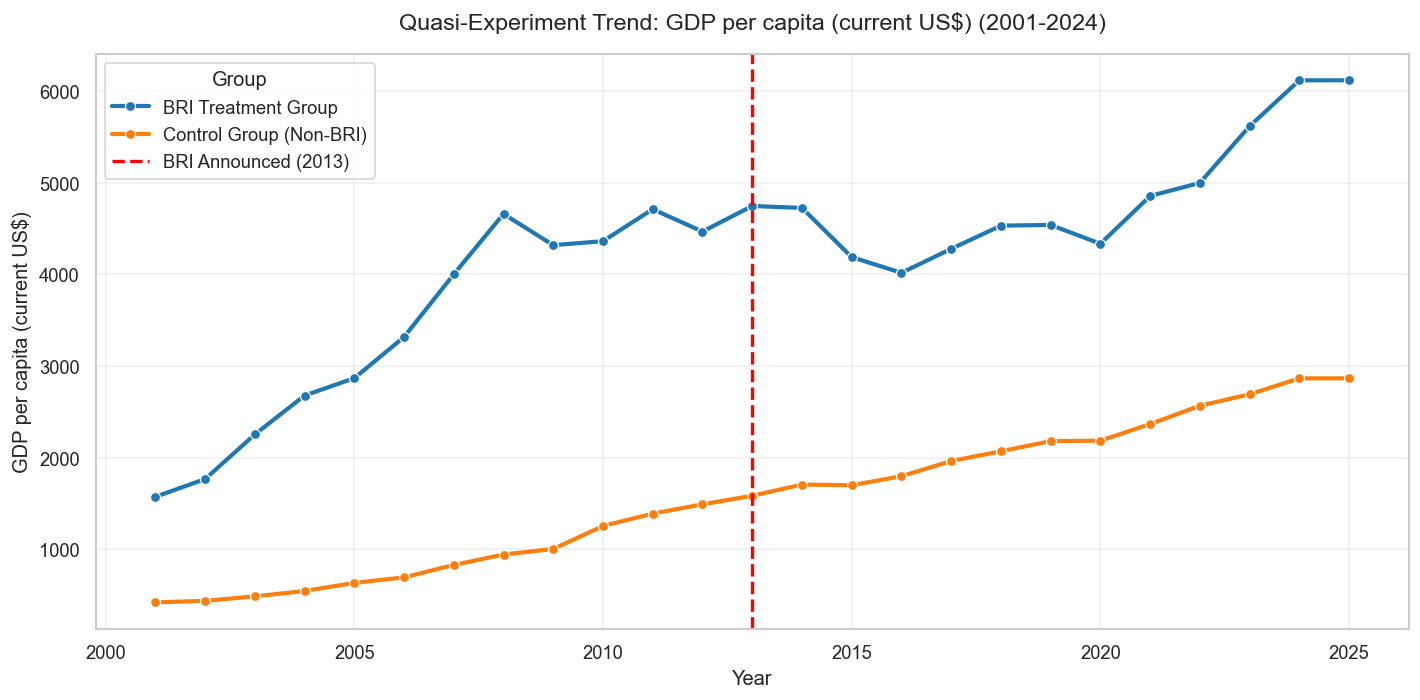

In [16]:
def plot_trend_with_intervention(df, indicator_col, intervention_year=2013):
    plt.figure(figsize=(12, 6))
    
    plot_data = df[df['DID_Group'] != 'China']
    
    sns.lineplot(data=plot_data, x='Year', y=indicator_col, 
                 hue='DID_Group', estimator='mean', errorbar=None, 
                 marker='o', linewidth=2.5, palette=['#1f77b4', '#ff7f0e'])
    
    plt.axvline(x=intervention_year, color='red', linestyle='--', linewidth=2, label=f'BRI Announced ({intervention_year})')
    
    plt.title(f'Quasi-Experiment Trend: {indicator_col} (2001-2024)', fontsize=14, pad=15)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(indicator_col, fontsize=12)
    plt.legend(title='Group')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_trend_with_intervention(df_imputed, 'GDP per capita (current US$)')

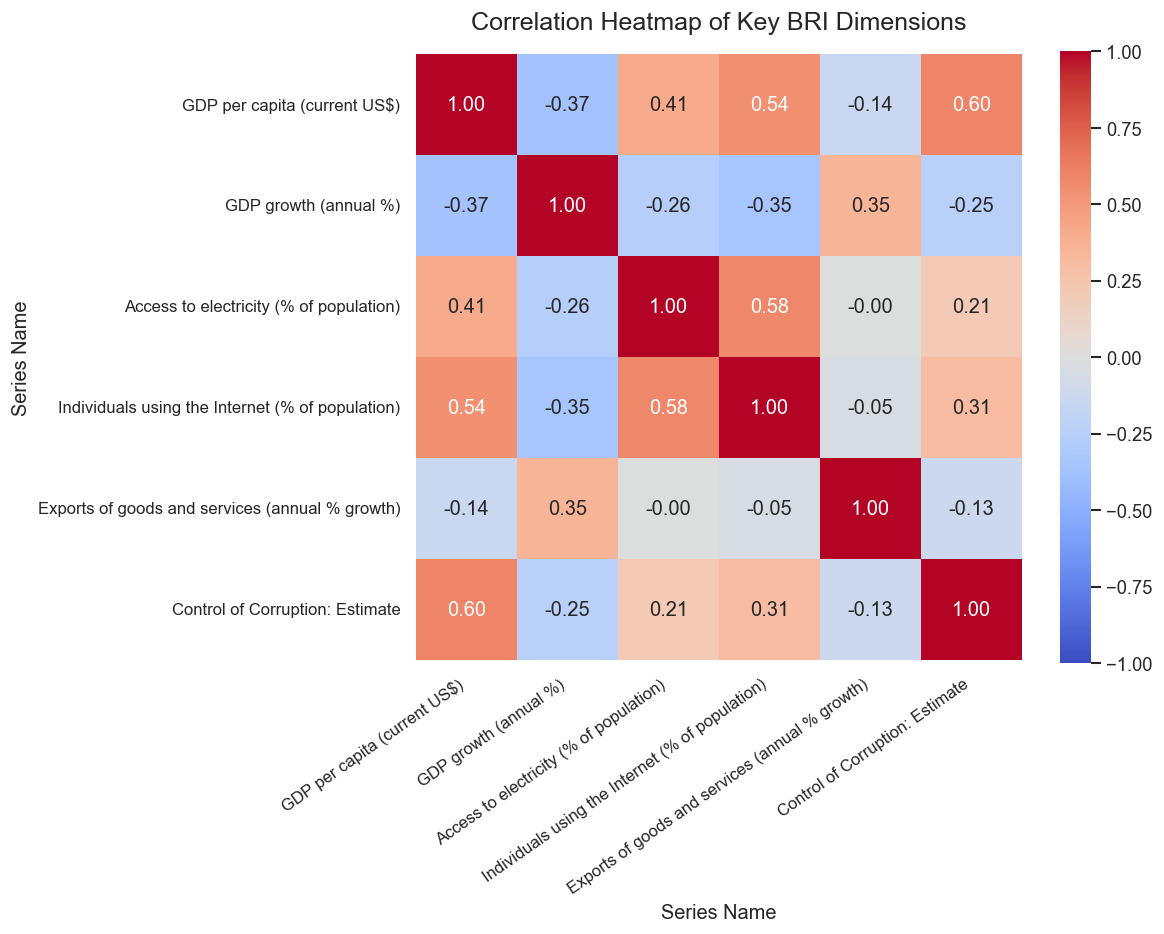

In [17]:
key_indicators = [
    'GDP per capita (current US$)', 
    'GDP growth (annual %)',
    'Access to electricity (% of population)', 
    'Individuals using the Internet (% of population)',
    'Exports of goods and services (annual % growth)',
    'Control of Corruption: Estimate'
]

valid_indicators = [col for col in key_indicators if col in df_imputed.columns]

corr_matrix = df_imputed[valid_indicators].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, square=True)

plt.title('Correlation Heatmap of Key BRI Dimensions', fontsize=15, pad=15)
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [18]:
df_imputed.to_csv('Final_Imputed_Panel_Data.csv', index=False)
print("cleaned dataset saved as: Final_Imputed_Panel_Data.csv")

cleaned dataset saved as: Final_Imputed_Panel_Data.csv
